 Mount Drive & Import Config

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/sentiment-robustness-id/src')
from config import *

print(f'ROOT : {ROOT}')
print('✅ Config loaded')

Mounted at /content/drive
ROOT : /content/drive/MyDrive/sentiment-robustness-id
✅ Config loaded


Copy dataset ke Lokal

In [2]:
# ============================================================
# Copy Dataset ke Lokal Colab
# Hanya untuk notebook training (04 & 05)
# Tujuan: mempercepat I/O saat training
# Catatan: output (model, hasil) tetap disimpan ke Drive
# ============================================================

import shutil, time

LOCAL_ROOT = '/content/local_project'

files_to_copy = {
    'processed'  : (PROCESSED_DATA_PATH, f'{LOCAL_ROOT}/data/processed/data_clean.csv'),
    'test_clean' : (TEST_CLEAN_PATH,     f'{LOCAL_ROOT}/data/noisy/test_clean.csv'),
    'noise_10'   : (TEST_NOISE_10_PATH,  f'{LOCAL_ROOT}/data/noisy/test_noise_10.csv'),
    'noise_20'   : (TEST_NOISE_20_PATH,  f'{LOCAL_ROOT}/data/noisy/test_noise_20.csv'),
    'noise_30'   : (TEST_NOISE_30_PATH,  f'{LOCAL_ROOT}/data/noisy/test_noise_30.csv'),
}

for folder in [
    f'{LOCAL_ROOT}/data/processed',
    f'{LOCAL_ROOT}/data/noisy',
]:
    os.makedirs(folder, exist_ok=True)

print('=== COPYING DATASET TO LOCAL COLAB ===\n')
for name, (src, dst) in files_to_copy.items():
    t0 = time.time()
    shutil.copy2(src, dst)
    size_mb = os.path.getsize(dst) / (1024 ** 2)
    elapsed = time.time() - t0
    print(f'  ✅ {name:<12} → {dst}')
    print(f'     Size: {size_mb:.2f} MB | Time: {elapsed:.2f}s')

# Override path baca → lokal
LOCAL_PROCESSED_DATA_PATH = f'{LOCAL_ROOT}/data/processed/data_clean.csv'
LOCAL_TEST_CLEAN_PATH     = f'{LOCAL_ROOT}/data/noisy/test_clean.csv'
LOCAL_TEST_NOISE_10_PATH  = f'{LOCAL_ROOT}/data/noisy/test_noise_10.csv'
LOCAL_TEST_NOISE_20_PATH  = f'{LOCAL_ROOT}/data/noisy/test_noise_20.csv'
LOCAL_TEST_NOISE_30_PATH  = f'{LOCAL_ROOT}/data/noisy/test_noise_30.csv'

print(f'\n✅ Baca data dari : {LOCAL_ROOT}')
print(f'   Simpan hasil ke: {ROOT} (Drive)')

=== COPYING DATASET TO LOCAL COLAB ===

  ✅ processed    → /content/local_project/data/processed/data_clean.csv
     Size: 3.29 MB | Time: 2.83s
  ✅ test_clean   → /content/local_project/data/noisy/test_clean.csv
     Size: 1.05 MB | Time: 1.02s
  ✅ noise_10     → /content/local_project/data/noisy/test_noise_10.csv
     Size: 1.11 MB | Time: 1.16s
  ✅ noise_20     → /content/local_project/data/noisy/test_noise_20.csv
     Size: 1.17 MB | Time: 0.97s
  ✅ noise_30     → /content/local_project/data/noisy/test_noise_30.csv
     Size: 1.21 MB | Time: 1.07s

✅ Baca data dari : /content/local_project
   Simpan hasil ke: /content/drive/MyDrive/sentiment-robustness-id (Drive)


Verifikasi GPU

In [3]:
import tensorflow as tf

print('=== GPU VERIFICATION ===')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(f'  ✅ GPU ditemukan : {gpu.name}')
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print('  Memory growth   : enabled')
else:
    print('  ⚠️  Tidak ada GPU. Pastikan runtime = T4 GPU di Colab.')
    print('     Runtime → Change runtime type → T4 GPU')

print(f'\n  TensorFlow versi : {tf.__version__}')
print(f'  Keras versi      : {tf.keras.__version__}')

=== GPU VERIFICATION ===
  ✅ GPU ditemukan : /physical_device:GPU:0
  Memory growth   : enabled

  TensorFlow versi : 2.19.0
  Keras versi      : 3.10.0


Import Library

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    Dense, Dropout, GlobalMaxPooling1D,
    SpatialDropout1D,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, CSVLogger,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
import random
SEED = RANDOM_STATE
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('✅ Semua library berhasil diimport')

✅ Semua library berhasil diimport


Load Dataset

In [5]:
# ============================================================
# Load processed data dan pisahkan berdasarkan kolom 'split'
# Membaca dari lokal Colab untuk mempercepat I/O
# ============================================================

df_all = pd.read_csv(LOCAL_PROCESSED_DATA_PATH)

df_train = df_all[df_all['split'] == 'train'].reset_index(drop=True)
df_val   = df_all[df_all['split'] == 'val'].reset_index(drop=True)
df_test  = df_all[df_all['split'] == 'test'].reset_index(drop=True)

X_train, y_train = df_train['tweet_clean'].values, df_train[LABEL_COLUMN].values
X_val,   y_val   = df_val['tweet_clean'].values,   df_val[LABEL_COLUMN].values
X_test,  y_test  = df_test['tweet_clean'].values,  df_test[LABEL_COLUMN].values

print('=== DATASET LOADED ===')
print(f'  Sumber  : {LOCAL_PROCESSED_DATA_PATH}')
print(f'  Train   : {len(X_train):,} sampel')
print(f'  Val     : {len(X_val):,} sampel')
print(f'  Test    : {len(X_test):,} sampel')

print('\n=== DISTRIBUSI LABEL ===')
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = pd.Series(y_split).value_counts().sort_index()
    dist   = ' | '.join([
        f'{LABEL_MAP[i]}: {counts[i]} ({counts[i]/len(y_split)*100:.1f}%)'
        for i in sorted(counts.index)
    ])
    print(f'  {split_name:6s}: {dist}')

=== DATASET LOADED ===
  Sumber  : /content/local_project/data/processed/data_clean.csv
  Train   : 16,310 sampel
  Val     : 3,495 sampel
  Test    : 3,495 sampel

=== DISTRIBUSI LABEL ===
  Train : Negatif: 1361 (8.3%) | Positif: 12192 (74.8%) | Netral: 2757 (16.9%)
  Val   : Negatif: 291 (8.3%) | Positif: 2613 (74.8%) | Netral: 591 (16.9%)
  Test  : Negatif: 291 (8.3%) | Positif: 2613 (74.8%) | Netral: 591 (16.9%)


Tokenisasi & Padding

In [7]:
# ============================================================
# Tokenisasi word-level menggunakan Keras Tokenizer
# Hanya difit pada train set — val & test menggunakan
# vocabulary yang sama untuk menghindari data leakage
# ============================================================

print('Fitting tokenizer pada train set...')
tokenizer = Tokenizer(
    num_words  = MAX_WORDS,
    oov_token  = '<OOV>',
    lower      = True,
    filters    = '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
)
tokenizer.fit_on_texts(X_train)

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print(f'  Vocabulary size (actual) : {len(tokenizer.word_index):,}')
print(f'  Vocabulary size (capped) : {vocab_size:,}')
print(f'  OOV token index          : {tokenizer.word_index.get("<OOV>", "N/A")}')

# Konversi teks → sequence integer
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Padding dengan post-padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

print(f'\n  Padding shape train : {X_train_pad.shape}')
print(f'  Padding shape val   : {X_val_pad.shape}')
print(f'  Padding shape test  : {X_test_pad.shape}')

# ---- FIX: Pastikan folder models/ ada sebelum simpan ----
tokenizer_path = f'{ROOT}/models/word_tokenizer.pkl'
os.makedirs(os.path.dirname(tokenizer_path), exist_ok=True)

with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f)
print(f'\n✅ Tokenizer disimpan : {tokenizer_path}')

Fitting tokenizer pada train set...
  Vocabulary size (actual) : 30,475
  Vocabulary size (capped) : 20,000
  OOV token index          : 1

  Padding shape train : (16310, 100)
  Padding shape val   : (3495, 100)
  Padding shape test  : (3495, 100)

✅ Tokenizer disimpan : /content/drive/MyDrive/sentiment-robustness-id/models/word_tokenizer.pkl


One-Hot Encoding Label & Class Weights

In [8]:
# ============================================================
# Konversi label integer → one-hot categorical
# Hitung class weights untuk menangani class imbalance
# ============================================================

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f'  y_train shape : {y_train_cat.shape}')
print(f'  y_val shape   : {y_val_cat.shape}')
print(f'  y_test shape  : {y_test_cat.shape}')

# Hitung class weights berdasarkan distribusi train set
class_weights_arr = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array(sorted(np.unique(y_train))),
    y            = y_train
)
class_weight_dict = {i: float(w) for i, w in enumerate(class_weights_arr)}

print('\n=== CLASS WEIGHTS ===')
for label_id, weight in class_weight_dict.items():
    print(f'  {LABEL_MAP[label_id]:10s} (label {label_id}) : {weight:.4f}')

  y_train shape : (16310, 3)
  y_val shape   : (3495, 3)
  y_test shape  : (3495, 3)

=== CLASS WEIGHTS ===
  Negatif    (label 0) : 3.9946
  Positif    (label 1) : 0.4459
  Netral     (label 2) : 1.9720


Arsitektur Baseline Model

In [13]:
# ============================================================
# BASELINE MODEL: Word Embedding + BiLSTM
#
# Arsitektur:
#   Input (word sequence)
#     ↓
#   Embedding Layer (trainable)
#     ↓
#   SpatialDropout1D           ← regularisasi pada embedding
#     ↓
#   Bidirectional LSTM         ← tangkap konteks dua arah
#     ↓
#   GlobalMaxPooling1D         ← ambil fitur paling dominan
#     ↓
#   Dense (128) + ReLU
#     ↓
#   Dropout
#     ↓
#   Dense (64) + ReLU
#     ↓
#   Dropout
#     ↓
#   Dense (NUM_CLASSES) + Softmax  ← output probabilitas
#
# Perubahan vs versi sebelumnya:
#   - mask_zero=False      → aktifkan GPU optimization
#   - recurrent_dropout=0  → aktifkan cuDNN kernel (10-20x lebih cepat)
#   - implementation=2     → matrix multiplication optimal untuk GPU
# ============================================================

def build_baseline_model(
    vocab_size    : int,
    embedding_dim : int,
    max_seq_len   : int,
    lstm_units    : int,
    num_classes   : int,
    dropout_rate  : float,
    learning_rate : float,
) -> Model:
    """
    Bangun model baseline BiLSTM untuk klasifikasi sentimen.

    Parameters
    ----------
    vocab_size    : ukuran vocabulary word tokenizer
    embedding_dim : dimensi embedding vector
    max_seq_len   : panjang maksimum sequence input
    lstm_units    : jumlah unit pada BiLSTM layer
    num_classes   : jumlah kelas output
    dropout_rate  : dropout rate untuk regularisasi
    learning_rate : learning rate optimizer Adam

    Returns
    -------
    model : tf.keras.Model — model yang siap di-compile
    """

    # ---- Input Layer ----
    word_input = Input(
        shape = (max_seq_len,),
        name  = 'word_input',
        dtype = 'int32',
    )

    # ---- Embedding Layer ----
    # mask_zero=False agar GPU bisa menggunakan optimasi penuh
    x = Embedding(
        input_dim    = vocab_size,
        output_dim   = embedding_dim,
        input_length = max_seq_len,
        mask_zero    = False,
        name         = 'word_embedding',
    )(word_input)

    # ---- Spatial Dropout ----
    # Dropout pada level feature map, lebih efektif dari regular dropout
    x = SpatialDropout1D(
        rate = dropout_rate * 0.5,
        name = 'spatial_dropout',
    )(x)

    # ---- Bidirectional LSTM ----
    # recurrent_dropout=0.0 agar cuDNN kernel aktif → jauh lebih cepat di GPU
    # implementation=2 menggunakan matrix multiplication optimal untuk GPU
    x = Bidirectional(
        LSTM(
            units             = lstm_units,
            return_sequences  = True,
            dropout           = dropout_rate * 0.5,
            recurrent_dropout = 0.0,
            implementation    = 2,
        ),
        name = 'bilstm',
    )(x)

    # ---- Global Max Pooling ----
    # Ambil nilai maksimum dari setiap fitur sepanjang sequence
    x = GlobalMaxPooling1D(name='global_max_pool')(x)

    # ---- Dense Block 1 ----
    x = Dense(128, activation='relu', name='dense_1')(x)
    x = Dropout(dropout_rate, name='dropout_1')(x)

    # ---- Dense Block 2 ----
    x = Dense(64, activation='relu', name='dense_2')(x)
    x = Dropout(dropout_rate * 0.5, name='dropout_2')(x)

    # ---- Output Layer ----
    output = Dense(
        units      = num_classes,
        activation = 'softmax',
        name       = 'output',
    )(x)

    # ---- Compile ----
    model = Model(inputs=word_input, outputs=output, name='Baseline_BiLSTM')
    model.compile(
        optimizer = Adam(learning_rate=learning_rate),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy'],
    )
    return model


# ---- Instansiasi Model ----
baseline_model = build_baseline_model(
    vocab_size    = vocab_size,
    embedding_dim = EMBEDDING_DIM,
    max_seq_len   = MAX_SEQ_LEN,
    lstm_units    = LSTM_UNITS,
    num_classes   = NUM_CLASSES,
    dropout_rate  = DROPOUT_RATE,
    learning_rate = LEARNING_RATE,
)

baseline_model.summary()

# Hitung total parameter
total_params     = baseline_model.count_params()
trainable_params = sum([
    tf.size(w).numpy() for w in baseline_model.trainable_weights
])
print(f'\n  Total params     : {total_params:,}')
print(f'  Trainable params : {trainable_params:,}')

Model: "Baseline_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word_input (InputLayer)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ word_embedding (Embedding)      │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,683,779 (10.24 MB)

 Trainable params: 2,683,779 (10.24 MB)

 Non-trainable params: 0 (0.00 B)


  Total params     : 2,683,779
  Trainable params : 2,683,779


Visualisasi Arsitektur Model

✅ Diagram arsitektur disimpan: /content/drive/MyDrive/sentiment-robustness-id/results/plots/04_baseline_architecture.png


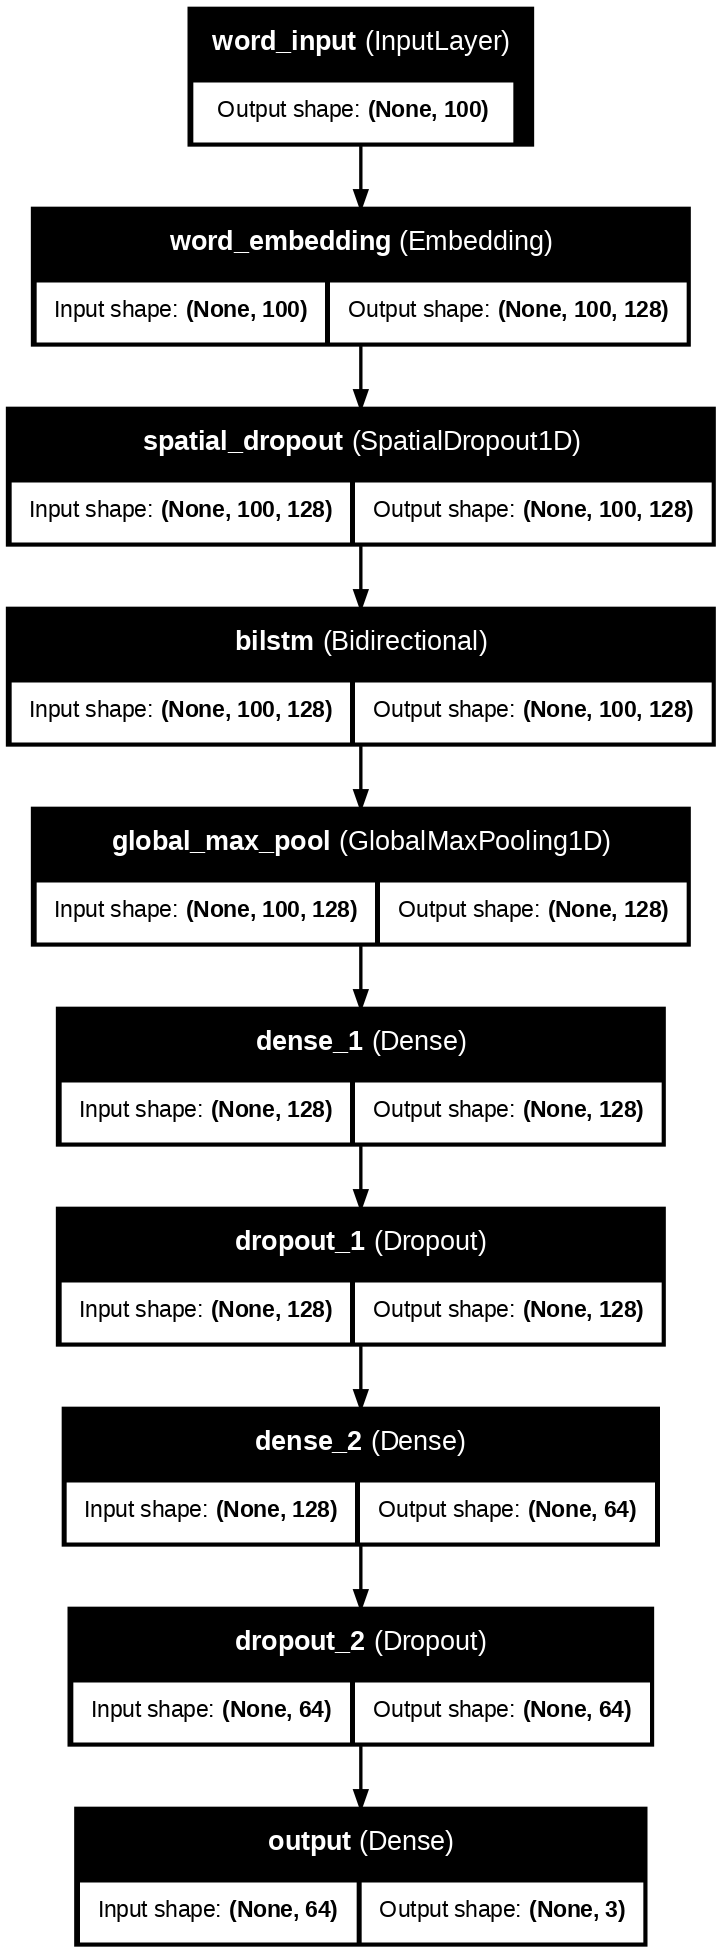

In [14]:
# ============================================================
# Simpan diagram arsitektur model sebagai gambar
# ============================================================

arch_path = f'{PLOTS_DIR}/04_baseline_architecture.png'

tf.keras.utils.plot_model(
    baseline_model,
    to_file        = arch_path,
    show_shapes    = True,
    show_dtype     = False,
    show_layer_names    = True,
    rankdir        = 'TB',    # Top-Bottom
    expand_nested  = True,
    dpi            = 120,
)

print(f'✅ Diagram arsitektur disimpan: {arch_path}')

# Tampilkan
from IPython.display import Image
Image(arch_path)

Callbacks Training

In [15]:
# ============================================================
# Callbacks untuk mengontrol proses training secara otomatis
# ============================================================

log_path      = f'{RESULTS_DIR}/baseline_training_log.csv'
checkpoint_path = BASELINE_MODEL_PATH

callbacks = [

    # 1. Early Stopping
    # Hentikan training jika val_loss tidak membaik setelah 5 epoch
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 5,
        restore_best_weights = True,   # rollback ke bobot terbaik
        verbose              = 1,
        mode                 = 'min',
    ),

    # 2. Model Checkpoint
    # Simpan bobot terbaik berdasarkan val_loss
    ModelCheckpoint(
        filepath         = checkpoint_path,
        monitor          = 'val_loss',
        save_best_only   = True,
        save_weights_only= False,
        verbose          = 1,
        mode             = 'min',
    ),

    # 3. Reduce LR on Plateau
    # Kurangi learning rate jika val_loss stagnan 3 epoch
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,        # lr baru = lr lama * 0.5
        patience = 3,
        min_lr   = 1e-6,
        verbose  = 1,
        mode     = 'min',
    ),

    # 4. CSV Logger
    # Simpan history training ke file CSV untuk analisis
    CSVLogger(
        filename = log_path,
        append   = False,
    ),
]

print('=== CALLBACKS CONFIGURED ===')
print(f'  EarlyStopping       : patience=5, monitor=val_loss')
print(f'  ModelCheckpoint     : {checkpoint_path}')
print(f'  ReduceLROnPlateau   : factor=0.5, patience=3')
print(f'  CSVLogger           : {log_path}')

=== CALLBACKS CONFIGURED ===
  EarlyStopping       : patience=5, monitor=val_loss
  ModelCheckpoint     : /content/drive/MyDrive/sentiment-robustness-id/models/baseline_model.h5
  ReduceLROnPlateau   : factor=0.5, patience=3
  CSVLogger           : /content/drive/MyDrive/sentiment-robustness-id/results/baseline_training_log.csv


Training Baseline Model

In [16]:
# ============================================================
# Training loop
# Train set → clean only
# Val set   → clean only
# Catatan: model tidak pernah melihat noisy data
# ============================================================

print('=' * 50)
print('     TRAINING BASELINE MODEL')
print('=' * 50)
print(f'  Epochs      : {EPOCHS}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Optimizer   : Adam (lr={LEARNING_RATE})')
print(f'  Loss        : categorical_crossentropy')
print('=' * 50)

history = baseline_model.fit(
    x               = X_train_pad,
    y               = y_train_cat,
    validation_data = (X_val_pad, y_val_cat),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    class_weight    = class_weight_dict,
    callbacks       = callbacks,
    verbose         = 1,
)

print(f'\n✅ Training selesai')
print(f'   Epoch terbaik   : {np.argmin(history.history["val_loss"]) + 1}')
print(f'   Best val_loss   : {min(history.history["val_loss"]):.4f}')
print(f'   Best val_acc    : {max(history.history["val_accuracy"]):.4f}')

     TRAINING BASELINE MODEL
  Epochs      : 20
  Batch size  : 64
  Optimizer   : Adam (lr=0.001)
  Loss        : categorical_crossentropy
Epoch 1/20
254/255 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5642 - loss: 0.9766
Epoch 1: val_loss improved from inf to 0.52681, saving model to /content/drive/MyDrive/sentiment-robustness-id/models/baseline_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.5649 - loss: 0.9754 - val_accuracy: 0.7934 - val_loss: 0.5268 - learning_rate: 0.0010
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8199 - loss: 0.5099
Epoch 2: val_loss improved from 0.52681 to 0.47981, saving model to /content/drive/MyDrive/sentiment-robustness-id/models/baseline_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8200 - loss: 0.5096 - val_accuracy: 0.8140 - val_loss: 0.4798 - learning_rate: 0.0010
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9034 - loss: 0.2583
Epoch 3: val_loss did not improve from 0.47981
255/255 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9034 - loss: 0.2582 - val_accuracy: 0.8260 - val_loss: 0.5469 - learning_rate: 0.0010
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9420 - loss: 0.1483
Epoch 4: val_loss did not improve from 0.47981
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9420 - loss: 0.1482 - val_accuracy: 0.8260 - val_loss: 0.6028 - learning_rate: 0.0010
Epoch 5/20
253/255 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9631 - loss: 0.0935
Epoch 5: val_loss did not improve from 0.47981

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9631 - loss: 0.0934 - val_accuracy: 0.8

Visualisasi Learning Curve

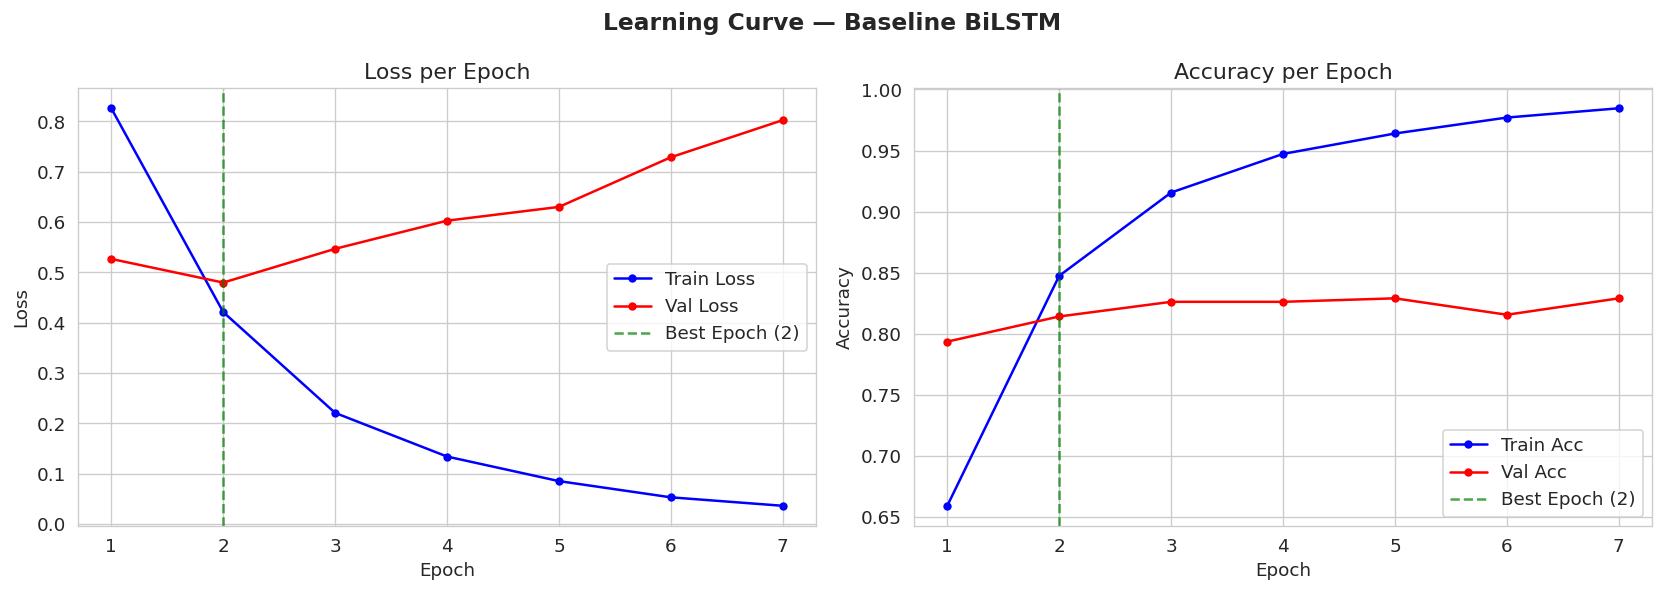

✅ Plot disimpan: /content/drive/MyDrive/sentiment-robustness-id/results/plots/04_baseline_learning_curve.png


In [17]:
def plot_learning_curve(history: dict, model_name: str, save_path: str) -> None:
    """
    Plot training & validation loss dan accuracy per epoch.
    Tandai epoch terbaik dengan garis vertikal.
    """
    epochs_ran  = range(1, len(history['loss']) + 1)
    best_epoch  = np.argmin(history['val_loss']) + 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Learning Curve — {model_name}', fontsize=14, fontweight='bold')

    # ---- Loss ----
    axes[0].plot(epochs_ran, history['loss'],     'b-o', markersize=4, label='Train Loss')
    axes[0].plot(epochs_ran, history['val_loss'], 'r-o', markersize=4, label='Val Loss')
    axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7,
                    label=f'Best Epoch ({best_epoch})')
    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # ---- Accuracy ----
    axes[1].plot(epochs_ran, history['accuracy'],     'b-o', markersize=4, label='Train Acc')
    axes[1].plot(epochs_ran, history['val_accuracy'], 'r-o', markersize=4, label='Val Acc')
    axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7,
                    label=f'Best Epoch ({best_epoch})')
    axes[1].set_title('Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'✅ Plot disimpan: {save_path}')


plot_learning_curve(
    history    = history.history,
    model_name = 'Baseline BiLSTM',
    save_path  = f'{PLOTS_DIR}/04_baseline_learning_curve.png',
)

Fungsi Evaluasi Model

In [20]:
def evaluate_on_testset(
    model       : Model,
    X_padded    : np.ndarray,
    y_true      : np.ndarray,
    label_map   : dict,
    dataset_name: str,
    batch_size  : int = 64,
) -> dict:
    """
    Evaluasi model pada satu test set.
    Kembalikan dictionary metrik lengkap.

    Parameters
    ----------
    model        : trained Keras model
    X_padded     : input array yang sudah di-pad
    y_true       : label integer ground truth
    label_map    : mapping {int: str} untuk nama kelas
    dataset_name : nama dataset untuk logging
    batch_size   : batch size saat inference

    Returns
    -------
    metrics : dict — accuracy, macro_f1, weighted_f1,
                     per_class_f1, confusion_matrix
    """
    # Prediksi probabilitas
    y_prob = model.predict(X_padded, batch_size=batch_size, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # Hitung metrik
    acc         = accuracy_score(y_true, y_pred)
    macro_f1    = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm          = confusion_matrix(y_true, y_pred)
    report      = classification_report(
        y_true, y_pred,
        target_names = [label_map[i] for i in sorted(label_map)],
        output_dict  = True,
        zero_division= 0,
    )

    # Per-class F1
    per_class_f1 = {
        label_map[i]: report[label_map[i]]['f1-score']
        for i in sorted(label_map)
    }

    metrics = {
        'dataset'       : dataset_name,
        'accuracy'      : round(acc, 4),
        'macro_f1'      : round(macro_f1, 4),
        'weighted_f1'   : round(weighted_f1, 4),
        'per_class_f1'  : per_class_f1,
        'confusion_matrix': cm.tolist(),
        'report'        : report,
    }

    print(f'\n{"=" * 50}')
    print(f'  EVALUASI — {dataset_name}')
    print(f'{"=" * 50}')
    print(f'  Accuracy      : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Macro F1      : {macro_f1:.4f}')
    print(f'  Weighted F1   : {weighted_f1:.4f}')
    print(f'\n  Per-Class F1:')
    for cls, f1 in per_class_f1.items():
        print(f'    {cls:10s}: {f1:.4f}')

    return metrics

Load Semua Noisy Test Set & Evaluasi

In [19]:
# ============================================================
# Tokenisasi semua noisy test set menggunakan tokenizer
# yang sudah di-fit pada train set (tidak re-fit)
# Membaca dari lokal Colab untuk mempercepat I/O
# ============================================================

def load_and_tokenize_noisy(
    path       : str,
    tokenizer  : Tokenizer,
    max_seq_len: int,
) -> tuple:
    """
    Load noisy test set dari CSV, tokenisasi, dan padding.

    Parameters
    ----------
    path        : str       — path ke file CSV noisy test set
    tokenizer   : Tokenizer — tokenizer yang sudah di-fit pada train set
    max_seq_len : int       — panjang maksimum sequence

    Returns
    -------
    X_pad  : np.ndarray — padded sequences
    y_true : np.ndarray — label integer
    """
    df    = pd.read_csv(path)
    texts = df['tweet_noisy'].fillna('').values
    y     = df[LABEL_COLUMN].values

    seqs  = tokenizer.texts_to_sequences(texts)
    X_pad = pad_sequences(
        seqs,
        maxlen    = max_seq_len,
        padding   = 'post',
        truncating= 'post',
    )
    return X_pad, y


# ---- Load semua versi dari lokal ----
print('Loading & tokenisasi noisy test sets dari lokal...\n')

X_clean, y_clean = load_and_tokenize_noisy(LOCAL_TEST_CLEAN_PATH,    tokenizer, MAX_SEQ_LEN)
X_n10,   y_n10   = load_and_tokenize_noisy(LOCAL_TEST_NOISE_10_PATH, tokenizer, MAX_SEQ_LEN)
X_n20,   y_n20   = load_and_tokenize_noisy(LOCAL_TEST_NOISE_20_PATH, tokenizer, MAX_SEQ_LEN)
X_n30,   y_n30   = load_and_tokenize_noisy(LOCAL_TEST_NOISE_30_PATH, tokenizer, MAX_SEQ_LEN)

print(f'  Sumber  : {LOCAL_ROOT}/data/noisy/')
print(f'  Clean   : {X_clean.shape}')
print(f'  10%     : {X_n10.shape}')
print(f'  20%     : {X_n20.shape}')
print(f'  30%     : {X_n30.shape}')

# ---- Evaluasi pada semua versi ----
test_sets = [
    ('Clean (0%)', X_clean, y_clean),
    ('Noise 10%',  X_n10,   y_n10),
    ('Noise 20%',  X_n20,   y_n20),
    ('Noise 30%',  X_n30,   y_n30),
]

baseline_results = []
for name, X_pad, y_true in test_sets:
    metrics = evaluate_on_testset(
        model        = baseline_model,
        X_padded     = X_pad,
        y_true       = y_true,
        label_map    = LABEL_MAP,
        dataset_name = name,
    )
    baseline_results.append(metrics)

Loading & tokenisasi noisy test sets dari lokal...

  Sumber  : /content/local_project/data/noisy/
  Clean   : (3495, 100)
  10%     : (3495, 100)
  20%     : (3495, 100)
  30%     : (3495, 100)

  EVALUASI — Clean (0%)
  Accuracy      : 0.8243 (82.43%)
  Macro F1      : 0.7197
  Weighted F1   : 0.8352

  Per-Class F1:
    Negatif   : 0.5642
    Positif   : 0.8962
    Netral    : 0.6988

  EVALUASI — Noise 10%
  Accuracy      : 0.8203 (82.03%)
  Macro F1      : 0.7101
  Weighted F1   : 0.8316

  Per-Class F1:
    Negatif   : 0.5495
    Positif   : 0.8963
    Netral    : 0.6845

  EVALUASI — Noise 20%
  Accuracy      : 0.8129 (81.29%)
  Macro F1      : 0.6971
  Weighted F1   : 0.8254

  Per-Class F1:
    Negatif   : 0.5240
    Positif   : 0.8932
    Netral    : 0.6741

  EVALUASI — Noise 30%
  Accuracy      : 0.7991 (79.91%)
  Macro F1      : 0.6817
  Weighted F1   : 0.8138

  Per-Class F1:
    Negatif   : 0.4931
    Positif   : 0.8820
    Netral    : 0.6698


Hitung Robustness Drop Rate

In [21]:
# ============================================================
# Robustness Drop Rate mengukur seberapa besar performa
# model menurun akibat noise
#
# Formula:
#   Drop(%) = (Score_clean - Score_noisy) / Score_clean × 100
#
# Semakin kecil drop rate → model semakin robust
# ============================================================

def compute_drop_rate(score_clean: float, score_noisy: float) -> float:
    """Hitung persentase penurunan performa akibat noise."""
    if score_clean == 0:
        return 0.0
    return round((score_clean - score_noisy) / score_clean * 100, 2)


acc_clean = baseline_results[0]['accuracy']
f1_clean  = baseline_results[0]['macro_f1']

print('=== ROBUSTNESS DROP RATE — BASELINE MODEL ===\n')
print(f'{"Dataset":<15} {"Accuracy":>10} {"Drop Acc%":>10} {"Macro F1":>10} {"Drop F1%":>10}')
print('-' * 58)

drop_summary = []
for res in baseline_results:
    drop_acc = compute_drop_rate(acc_clean, res['accuracy'])
    drop_f1  = compute_drop_rate(f1_clean,  res['macro_f1'])
    drop_summary.append({
        'model'     : 'Baseline',
        'dataset'   : res['dataset'],
        'accuracy'  : res['accuracy'],
        'macro_f1'  : res['macro_f1'],
        'drop_acc'  : drop_acc,
        'drop_f1'   : drop_f1,
    })
    print(f'{res["dataset"]:<15} {res["accuracy"]:>10.4f} {drop_acc:>9.2f}% '
          f'{res["macro_f1"]:>10.4f} {drop_f1:>9.2f}%')

# Simpan ke DataFrame untuk notebook 06
df_baseline_drops = pd.DataFrame(drop_summary)
df_baseline_drops.to_csv(f'{RESULTS_DIR}/metrics_baseline.csv', index=False)
print(f'\n✅ Hasil disimpan: {RESULTS_DIR}/metrics_baseline.csv')

=== ROBUSTNESS DROP RATE — BASELINE MODEL ===

Dataset           Accuracy  Drop Acc%   Macro F1   Drop F1%
----------------------------------------------------------
Clean (0%)          0.8243      0.00%     0.7197      0.00%
Noise 10%           0.8203      0.49%     0.7101      1.33%
Noise 20%           0.8129      1.38%     0.6971      3.14%
Noise 30%           0.7991      3.06%     0.6817      5.28%

✅ Hasil disimpan: /content/drive/MyDrive/sentiment-robustness-id/results/metrics_baseline.csv


Confusion Matrix per Test Set

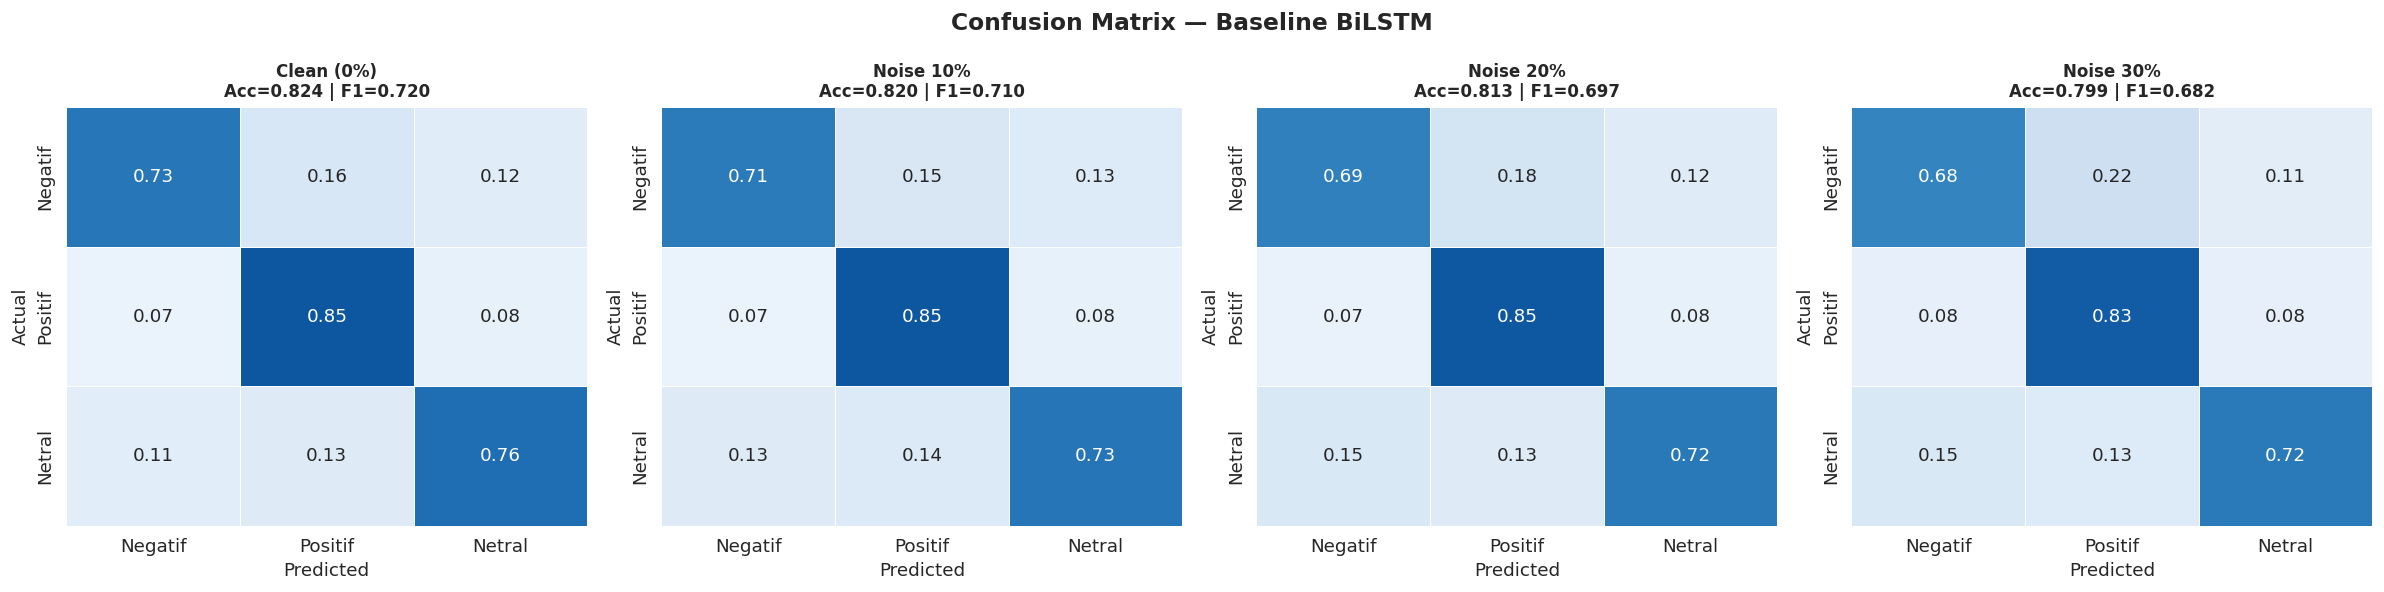

✅ Plot disimpan: /content/drive/MyDrive/sentiment-robustness-id/results/plots/04_baseline_confusion_matrix.png


In [22]:
def plot_confusion_matrices(
    results   : list,
    label_map : dict,
    model_name: str,
    save_path : str,
) -> None:
    """
    Plot confusion matrix untuk setiap test set dalam satu figure.
    Normalisasi per baris (recall-based) untuk kemudahan interpretasi.
    """
    n_sets  = len(results)
    fig, axes = plt.subplots(1, n_sets, figsize=(5 * n_sets, 5))
    fig.suptitle(f'Confusion Matrix — {model_name}', fontsize=14, fontweight='bold')

    labels = [label_map[i] for i in sorted(label_map)]

    for ax, res in zip(axes, results):
        cm     = np.array(res['confusion_matrix'])
        # Normalisasi per baris
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm,
            annot      = True,
            fmt        = '.2f',
            cmap       = 'Blues',
            xticklabels= labels,
            yticklabels= labels,
            ax         = ax,
            linewidths = 0.5,
            cbar       = False,
            vmin       = 0, vmax = 1,
        )
        ax.set_title(f'{res["dataset"]}\nAcc={res["accuracy"]:.3f} | F1={res["macro_f1"]:.3f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'✅ Plot disimpan: {save_path}')


plot_confusion_matrices(
    results    = baseline_results,
    label_map  = LABEL_MAP,
    model_name = 'Baseline BiLSTM',
    save_path  = f'{PLOTS_DIR}/04_baseline_confusion_matrix.png',
)

Visualisasi Robustness Curve

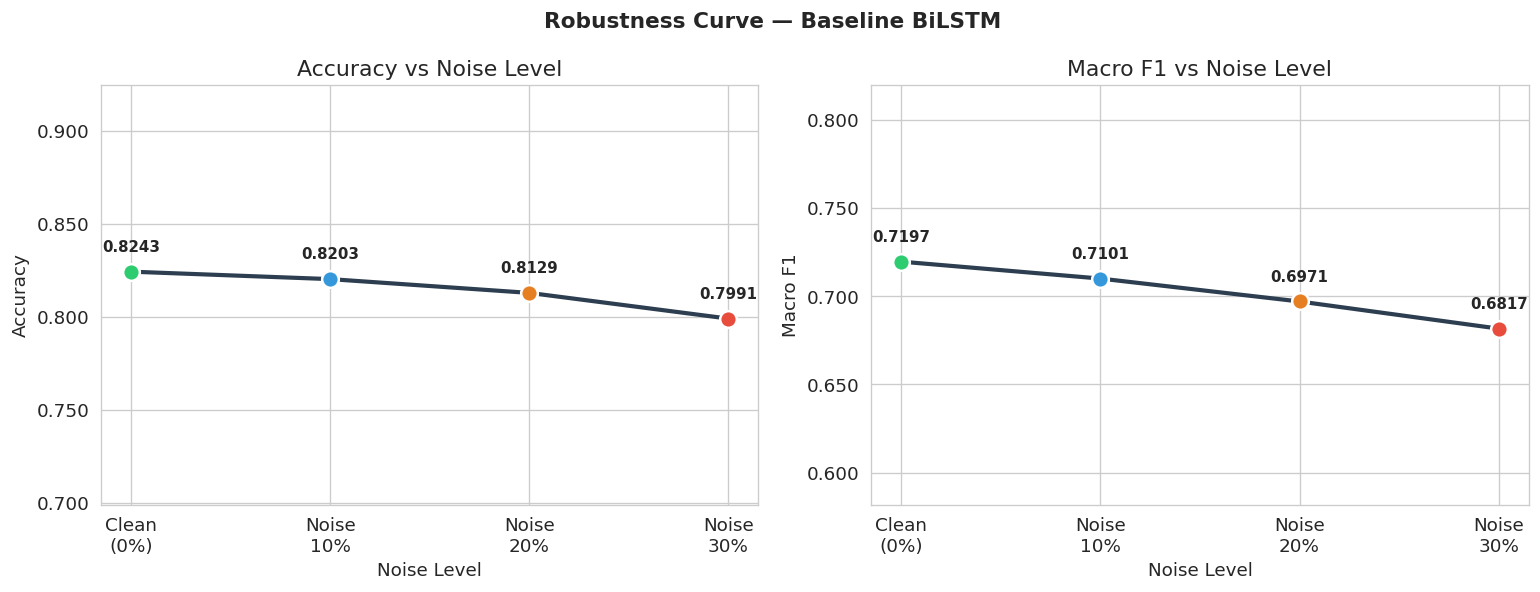

In [23]:
noise_labels  = ['Clean\n(0%)', 'Noise\n10%', 'Noise\n20%', 'Noise\n30%']
acc_values    = [r['accuracy']  for r in baseline_results]
f1_values     = [r['macro_f1']  for r in baseline_results]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Robustness Curve — Baseline BiLSTM', fontsize=13, fontweight='bold')

colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

for ax, values, metric_name in zip(axes, [acc_values, f1_values], ['Accuracy', 'Macro F1']):
    ax.plot(noise_labels, values, 'o-', color='#2c3e50', linewidth=2.5,
            markersize=8, zorder=5)
    for i, (x, y) in enumerate(zip(noise_labels, values)):
        ax.scatter(x, y, color=colors[i], s=100, zorder=6, edgecolors='white', linewidths=1.5)
        ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'{metric_name} vs Noise Level')
    ax.set_xlabel('Noise Level')
    ax.set_ylabel(metric_name)
    ax.set_ylim(max(0, min(values) - 0.1), min(1.0, max(values) + 0.1))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_baseline_robustness_curve.png', bbox_inches='tight')
plt.show()

Ringkasan Baseline Model

In [24]:
print('=' * 58)
print('        RINGKASAN BASELINE MODEL')
print('=' * 58)

best_epoch = np.argmin(history.history['val_loss']) + 1

print(f'''
🏗️  ARSITEKTUR
  Model       : Baseline BiLSTM
  Input       : Word sequence (max_len={MAX_SEQ_LEN})
  Embedding   : Trainable ({vocab_size:,} × {EMBEDDING_DIM})
  BiLSTM      : {LSTM_UNITS} units × 2 arah
  Dense       : 128 → 64 → {NUM_CLASSES} (softmax)
  Total params: {baseline_model.count_params():,}

📈 TRAINING
  Best epoch  : {best_epoch}
  Best val_loss : {min(history.history["val_loss"]):.4f}
  Best val_acc  : {max(history.history["val_accuracy"]):.4f}

📊 ROBUSTNESS EVALUATION
  {"Dataset":<15} {"Accuracy":>10} {"Macro F1":>10} {"Drop Acc%":>10}
  {"-"*48}''')

for row in drop_summary:
    print(f'  {row["dataset"]:<15} {row["accuracy"]:>10.4f} '
          f'{row["macro_f1"]:>10.4f} {row["drop_acc"]:>9.2f}%')

print(f'''
💾 OUTPUT
  Model saved  : {BASELINE_MODEL_PATH}
  Metrics CSV  : {RESULTS_DIR}/metrics_baseline.csv
  Tokenizer    : {ROOT}/models/word_tokenizer.pkl

✅ Lanjut ke 05_Hybrid_Model.ipynb
   → Model baseline ini akan dijadikan pembanding utama
''')
print('=' * 58)

        RINGKASAN BASELINE MODEL

🏗️  ARSITEKTUR
  Model       : Baseline BiLSTM
  Input       : Word sequence (max_len=100)
  Embedding   : Trainable (20,000 × 128)
  BiLSTM      : 64 units × 2 arah
  Dense       : 128 → 64 → 3 (softmax)
  Total params: 2,683,779

📈 TRAINING
  Best epoch  : 2
  Best val_loss : 0.4798
  Best val_acc  : 0.8289

📊 ROBUSTNESS EVALUATION
  Dataset           Accuracy   Macro F1  Drop Acc%
  ------------------------------------------------
  Clean (0%)          0.8243     0.7197      0.00%
  Noise 10%           0.8203     0.7101      0.49%
  Noise 20%           0.8129     0.6971      1.38%
  Noise 30%           0.7991     0.6817      3.06%

💾 OUTPUT
  Model saved  : /content/drive/MyDrive/sentiment-robustness-id/models/baseline_model.h5
  Metrics CSV  : /content/drive/MyDrive/sentiment-robustness-id/results/metrics_baseline.csv
  Tokenizer    : /content/drive/MyDrive/sentiment-robustness-id/models/word_tokenizer.pkl

✅ Lanjut ke 05_Hybrid_Model.ipynb
   → Mo